In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("tips")

# Preview dataset
print(df.head())

# Dataset info
print(df.info())

# Convert 'sex' and 'smoker' to category type
df['sex'] = df['sex'].astype('category')
df['smoker'] = df['smoker'].astype('category')

# Create a new column: Tip Percentage
df['tip_pct'] = (df['tip'] / df['total_bill']) * 100

# Round to 2 decimal places
df['tip_pct'] = df['tip_pct'].round(2)

# Show updated data
print(df.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
   total_bill   tip     sex smoker  day    time  size  tip_pct
0       16.99  1.01  Female     No  Sun  Dinner     2     5.94


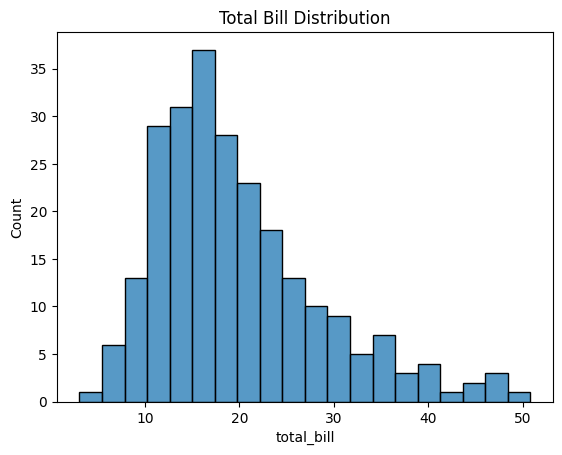

In [13]:
sns.histplot(df['total_bill'], bins=20)

plt.title("Total Bill Distribution")
plt.show()

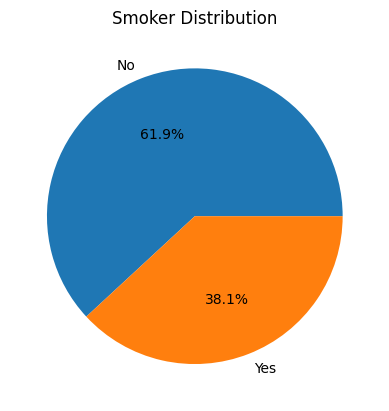

In [14]:
df['smoker'].value_counts().plot.pie(autopct='%1.1f%%')

plt.title("Smoker Distribution")
plt.ylabel("")
plt.show()

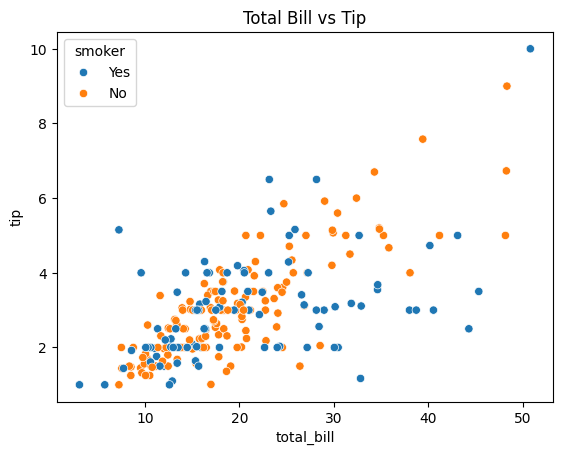

In [15]:
sns.scatterplot(x='total_bill', y='tip', hue='smoker', data=df)

plt.title("Total Bill vs Tip")
plt.show()

In [16]:
# Average tip percentage by gender

avg_tip_by_gender = df.groupby('sex')['tip_pct'].mean()

print(avg_tip_by_gender)

sex
Male      15.764713
Female    16.648276
Name: tip_pct, dtype: float64


C:\Users\AMIT PAUL\AppData\Local\Temp\ipykernel_12388\2385668932.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tip_by_gender = df.groupby('sex')['tip_pct'].mean()


In [17]:
# Round to 2 decimal places
df['tip_pct'] = df['tip_pct'].round(2)

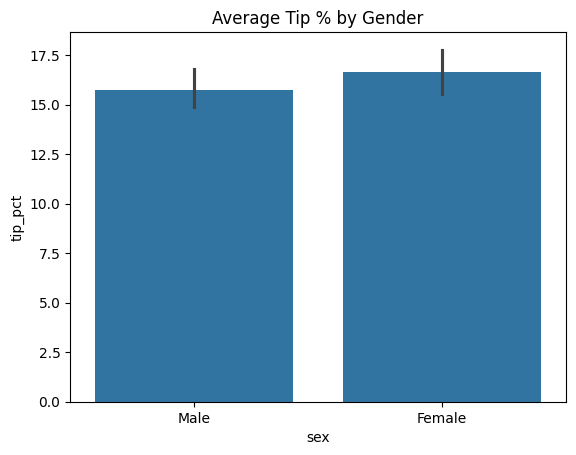

In [18]:
import matplotlib.pyplot as plt

# Bar plot: Tip % by gender
sns.barplot(x='sex', y='tip_pct', data=df)
plt.title("Average Tip % by Gender")
plt.show()

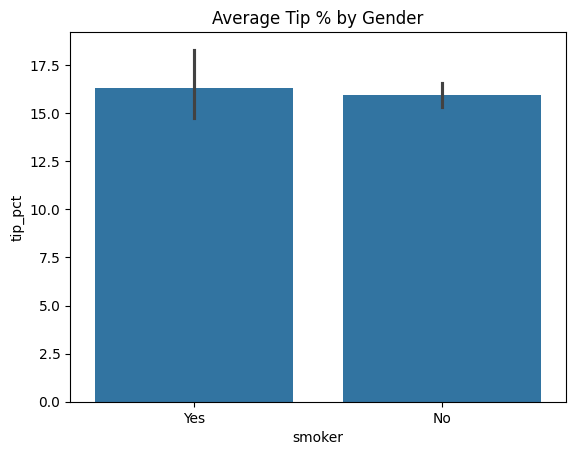

In [19]:
import matplotlib.pyplot as plt

# Bar plot: Tip % by gender
sns.barplot(x='smoker', y='tip_pct', data=df)
plt.title("Average Tip % by Gender")
plt.show()

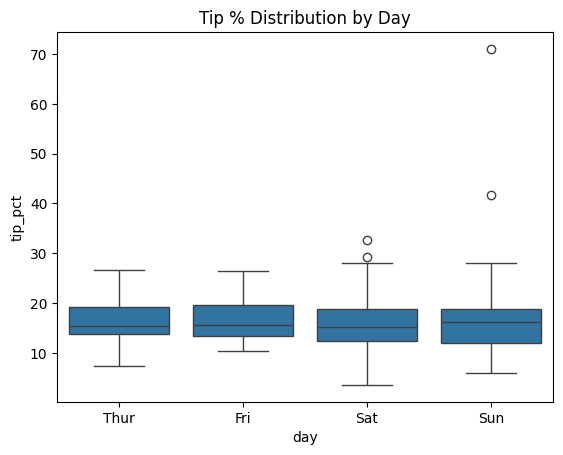

In [20]:
# Box plot: Tip % by day
sns.boxplot(x='day', y='tip_pct', data=df)

plt.title("Tip % Distribution by Day")
plt.show()

C:\Users\AMIT PAUL\AppData\Local\Temp\ipykernel_12388\3861292827.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  avg_tip_by_day_time = df.pivot_table(


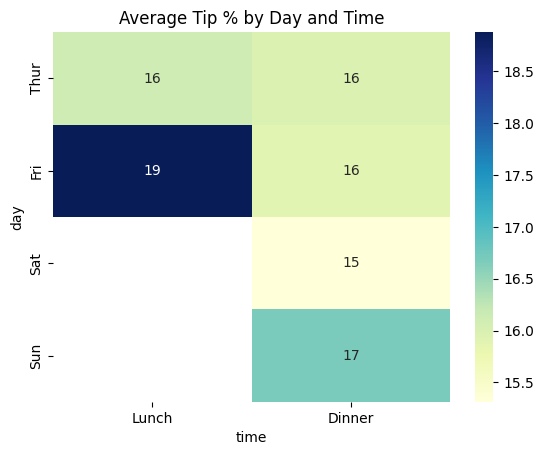

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("tips")

# Convert category types
df['sex'] = df['sex'].astype('category')
df['smoker'] = df['smoker'].astype('category')

# Create Tip Percentage
df['tip_pct'] = (df['tip'] / df['total_bill']) * 100
df['tip_pct'] = df['tip_pct'].round(2)

# Create pivot table
avg_tip_by_day_time = df.pivot_table(
    values='tip_pct',
    index='day',
    columns='time',
    aggfunc='mean'
)

# Heatmap
sns.heatmap(avg_tip_by_day_time, annot=True, cmap='YlGnBu')

plt.title("Average Tip % by Day and Time")
plt.show()

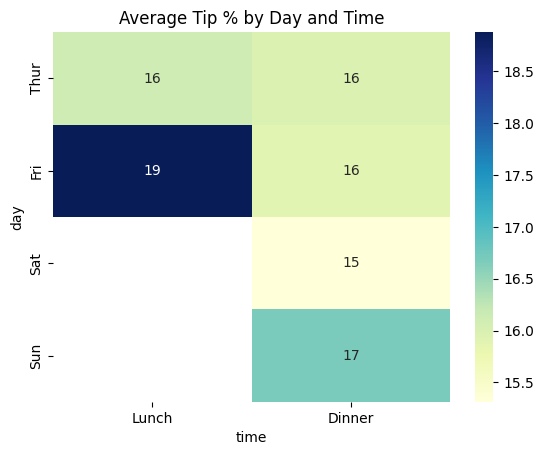

In [23]:
# Heatmap: Tip % by day and time
sns.heatmap(avg_tip_by_day_time, annot=True, cmap='YlGnBu')

plt.title("Average Tip % by Day and Time")
plt.show()

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import ttest_ind, chi2_contingency, shapiro
import statsmodels.api as sm
import statsmodels.formula.api as smf
    
titanic = sns.load_dataset("titanic")

                age                                     fare         \
               mean median        std         var       mean median   
survived                                                              
0         30.626179   28.0  14.172110  200.848698  22.117887   10.5   
1         28.343690   28.0  14.950952  223.530965  48.395408   26.0   

                                  
                std          var  
survived                          
0         31.388207   985.219509  
1         66.596998  4435.160158  


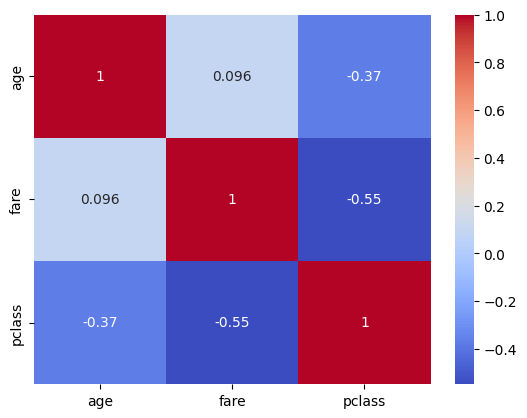

In [4]:

# 2. Enhanced Descriptive Statistics
# python

# Grouped descriptive stats
desc_stats = titanic.groupby("survived")[["age", "fare"]].agg(
    ["mean", "median", "std", "var"]
)

print(desc_stats)

# Correlation heatmap
sns.heatmap(titanic[["age", "fare", "pclass"]].corr(), annot=True, cmap="coolwarm")
plt.show()

In [6]:
# 3. Hypothesis Testing with Assumptions
# python

# Normality check (Shapiro-Wilk)
survivors = titanic.loc[titanic["survived"] == 1, "age"].dropna()
non_survivors = titanic.loc[titanic["survived"] == 0, "age"].dropna()

print("Shapiro survivors:", shapiro(survivors))
print("Shapiro non-survivors:", shapiro(non_survivors))




Shapiro survivors: ShapiroResult(statistic=0.982725820530032, pvalue=0.0014264515684873599)
Shapiro non-survivors: ShapiroResult(statistic=0.9689364580171806, pvalue=7.815528278627143e-08)


In [7]:
# t-test with effect size (Cohen's d)
t_stat, p_val = ttest_ind(survivors, non_survivors, equal_var=False)

cohens_d = (survivors.mean() - non_survivors.mean()) / np.sqrt(
    ((survivors.std()**2) + (non_survivors.std()**2)) / 2
)

print("t-test:", t_stat, p_val, "Cohen's d:", cohens_d)

t-test: -2.0460301043939704 0.04118965162586637 Cohen's d: -0.15669189080299373


In [8]:
# Chi-square with expected frequencies

contingency = pd.crosstab(titanic["survived"], titanic["class"])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2, p)

Chi-square: 102.88898875696056 4.549251711298793e-23
